In [1]:
import numpy as np
import warnings
import torch
import torch.nn as nn
import pandas as pd
import os
import importlib
import sys
from tqdm import tqdm
from torchvision import transforms
import torchvision.models as models 
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import optuna

batch_size = 256

import torchsummary


torch.manual_seed(42)

In [2]:
# 1. Konfiguration
REPO_URL = "https://github.com/828w5tjjts-wq/Machine-Learning-Final-project.git"
PROJECT_DIR = "/kaggle/working/Machine-Learning-Final-project"

# 2. Prüfen, ob das Repo schon existiert
if os.path.exists(PROJECT_DIR):
    print("Repo existiert bereits. Ziehe neueste Änderungen (Pull)...")
    %cd {PROJECT_DIR}
    !git pull origin main
else:
    print("Repo existiert nicht. Klone von GitHub...")
    !git clone {REPO_URL} {PROJECT_DIR}
    %cd {PROJECT_DIR}

# 3. Pfad zum System-Pfad hinzufügen (damit Imports funktionieren)
sys.path.append(PROJECT_DIR)

print("Setup abgeschlossen. Projekt ist aktuell.")

Repo existiert nicht. Klone von GitHub...
Cloning into '/kaggle/working/Machine-Learning-Final-project'...
remote: Enumerating objects: 170, done.
remote: Counting objects: 100% (170/170), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 170 (delta 72), reused 109 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (170/170), 1.34 MiB | 7.99 MiB/s, done.
Resolving deltas: 100% (72/72), done.
/kaggle/working/Machine-Learning-Final-project
Setup abgeschlossen. Projekt ist aktuell.


In [3]:
from src.models.architectures import MLPModel
from src.models.architectures import WideMLPModel
from src.models.architectures import MLPModel_V2
from src.models.architectures import MLPModel_V3
from src.models.architectures import DeepResidualMLP
from src.models.trainer import run_training
from src.data.loader import prepare_data
from src.data.loader import load_processed_data
from src.data.edit import split_data
from src.data.edit import standardize_data
from src.data.dataset import create_dataloaders
from src.models.tune import test_learning_rates
from src.models.tune import test_learning_rates_curves
from src.models.trainer import train_model_with_early_stopping
from src.data.cleaner import clean_target
from src.data.dataset import create_dataloaders

In [4]:
# DO NOT CHANGE
use_cuda = True
use_cuda = False if not use_cuda else torch.cuda.is_available()
device = torch.device('cuda:0' if use_cuda else 'cpu')
torch.cuda.get_device_name(device) if use_cuda else 'cpu'
print('Using device', device)

Using device cpu


In [5]:
X_raw, y = load_processed_data('/kaggle/input/datasets/nilsmatthiessen/processed-data/Machine-Learning-Final-project/X_filtered.npy'
,'/kaggle/input/datasets/nilsmatthiessen/processed-data/Machine-Learning-Final-project/y.npy' )

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_raw, y)
X_train_scaled, X_val_scaled, X_test_scaled = standardize_data(X_train, X_val, X_test)
    
train_loader, val_loader, test_loader = create_dataloaders(
    X_train_scaled, X_val_scaled, X_test_scaled, 
    y_train, y_val, y_test, 
    batch_size=batch_size
    )
print("\nAlles bereit für das Training!")

sample_inputs, _ = next(iter(train_loader))
input_dim = sample_inputs.shape[1]

model_linear = MLPModel(input_dim, 1)
model_linear = model_linear.to(device)

loss_function = torch.nn.MSELoss() # Mean Squared Error für Regression
optimizer = torch.optim.Adam(model_linear.parameters(), lr=0.1) 
num_epochs = 100


Daten geladen: X Shape (9229, 78), y Shape (9229,)
Split: Train=6460, Val=1384, Test=1385
Scaling abgeschlossen.
DataLoader bereit (Batch Size 256):
  Train Batches: 26
  Val Batches: 6
  Test Batches: 6

Alles bereit für das Training!


Starte Hyperparameter-Test für 4 Learning Rates (50 Epochen)...

--- Teste Learning Rate: 0.01 ---
LR 0.01 beendet. Finaler Val Loss: 237.5281

--- Teste Learning Rate: 0.001 ---
LR 0.001 beendet. Finaler Val Loss: 269.1951

--- Teste Learning Rate: 0.0001 ---
LR 0.0001 beendet. Finaler Val Loss: 17131.7318

--- Teste Learning Rate: 1e-05 ---
LR 1e-05 beendet. Finaler Val Loss: 24736.4762


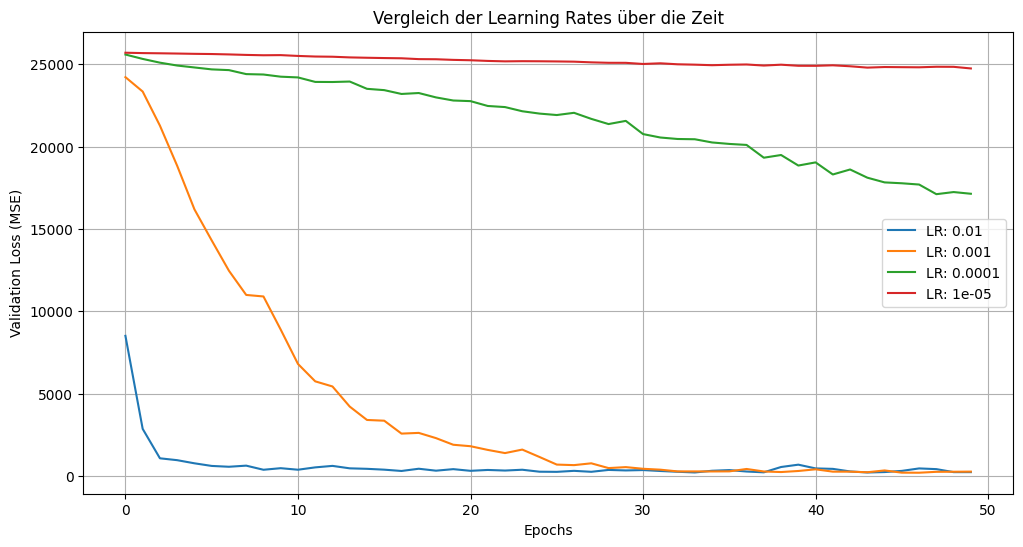


Bester finaler Val Loss bei LR: 0.01
Starte Hyperparameter-Test für 4 Learning Rates (50 Epochen)...

--- Teste Learning Rate: 0.01 ---
LR 0.01 beendet. Finaler Val Loss: 1829.6346

--- Teste Learning Rate: 0.001 ---
LR 0.001 beendet. Finaler Val Loss: 2011.7495

--- Teste Learning Rate: 0.0001 ---
LR 0.0001 beendet. Finaler Val Loss: 11552.5565

--- Teste Learning Rate: 1e-05 ---
LR 1e-05 beendet. Finaler Val Loss: 25559.2562


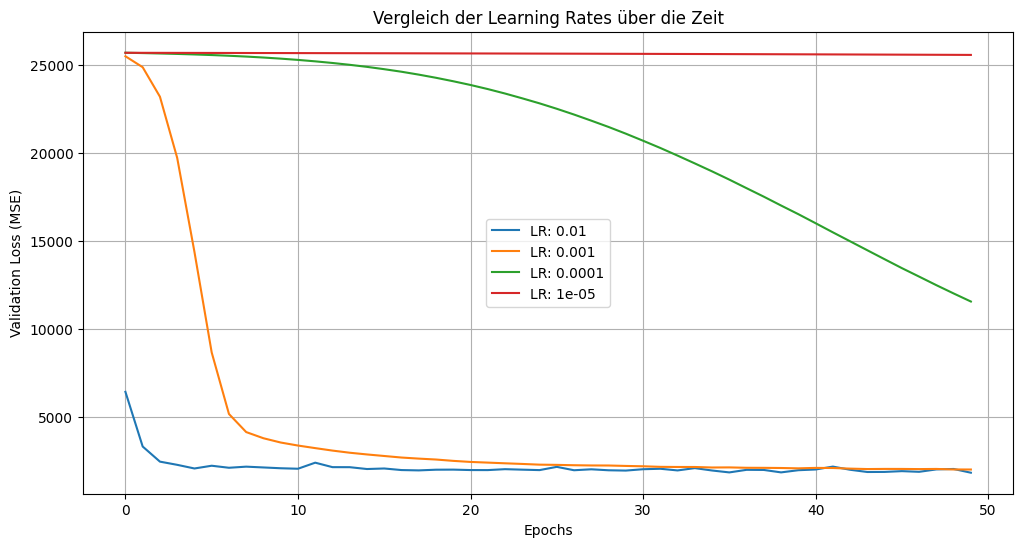


Bester finaler Val Loss bei LR: 0.01
Starte Hyperparameter-Test für 4 Learning Rates (50 Epochen)...

--- Teste Learning Rate: 0.01 ---
LR 0.01 beendet. Finaler Val Loss: 279.6899

--- Teste Learning Rate: 0.001 ---
LR 0.001 beendet. Finaler Val Loss: 181.4703

--- Teste Learning Rate: 0.0001 ---
LR 0.0001 beendet. Finaler Val Loss: 3292.0234

--- Teste Learning Rate: 1e-05 ---
LR 1e-05 beendet. Finaler Val Loss: 21543.3841


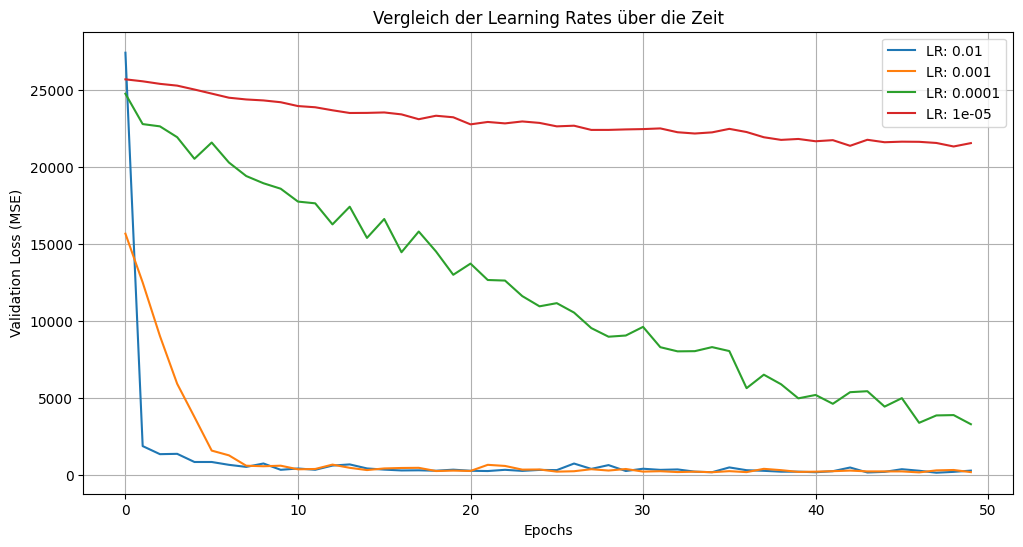


Bester finaler Val Loss bei LR: 0.001


In [6]:
learning_rates = [0.01,0.001,0.0001,0.00001]

all_loses_Wide = test_learning_rates_curves(
    learning_rates=learning_rates,
    model_class=WideMLPModel,
    input_dim=input_dim,
    output_dim=1,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=50
)
all_loses = test_learning_rates_curves(
    learning_rates=learning_rates,
    model_class=MLPModel,
    input_dim=input_dim,
    output_dim=1,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=50
)
all_loses_Deep = test_learning_rates_curves(
    learning_rates=learning_rates,
    model_class=DeepResidualMLP,
    input_dim=input_dim,
    output_dim=1,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=50
)


Starte Hyperparameter-Test für 7 Learning Rates (50 Epochen)...

--- Teste Learning Rate: 0.0001 ---
LR 0.0001 beendet. Finaler Val Loss: 16714.8130

--- Teste Learning Rate: 0.0002 ---
LR 0.0002 beendet. Finaler Val Loss: 7912.6506

--- Teste Learning Rate: 0.0003 ---
LR 0.0003 beendet. Finaler Val Loss: 3437.5584

--- Teste Learning Rate: 0.0004 ---
LR 0.0004 beendet. Finaler Val Loss: 1656.8196

--- Teste Learning Rate: 0.0005 ---
LR 0.0005 beendet. Finaler Val Loss: 566.1386

--- Teste Learning Rate: 0.0007 ---
LR 0.0007 beendet. Finaler Val Loss: 209.9292

--- Teste Learning Rate: 0.001 ---
LR 0.001 beendet. Finaler Val Loss: 283.2260


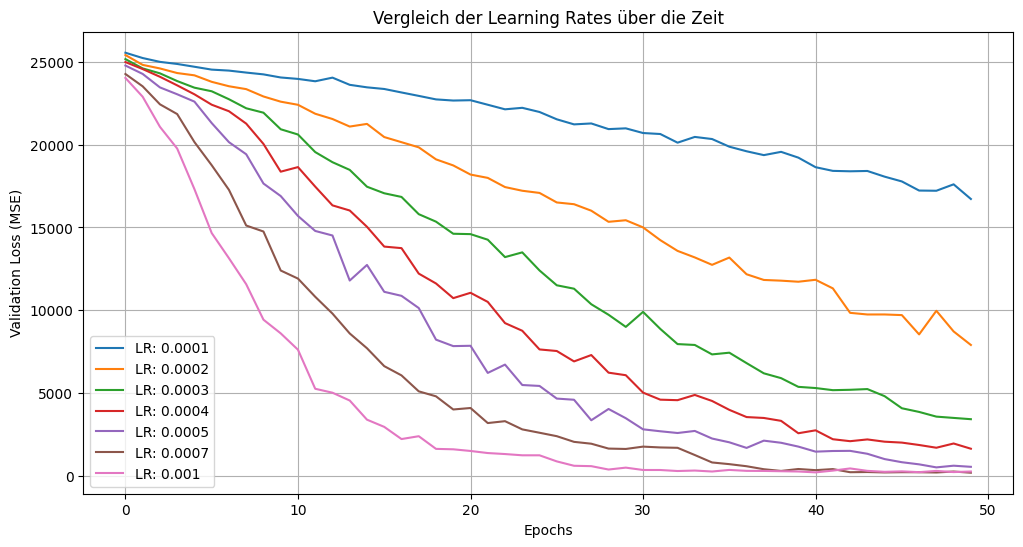


Bester finaler Val Loss bei LR: 0.0007


In [7]:
learning_rates = [0.0001,0.0002,0.0003,0.0004,0.0005,0.0007,0.001]

all_loses = test_learning_rates_curves(
    learning_rates=learning_rates,
    model_class=WideMLPModel,
    input_dim=input_dim,
    output_dim=1,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=50
)

In [8]:
model_mlp = WideMLPModel(input_dim=input_dim, output_dim=1).to(device)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=0.0007) 

In [9]:
train_losses, val_losses, train_rmses, val_rmses = run_training(
    model=model_mlp,
    optimizer=optimizer,
    loss_function=loss_function,
    device=device,
    num_epochs=50,
    train_dataloader=train_loader,
    val_dataloader=val_loader
)

Starte Training für 50 Epochen...


<div><p>Epoch 1/50 | Train Loss (MSE): 27665.5286 | Train RMSE:       167.06€ | Val Loss (MSE):   24310.1393 | Val RMSE:         156.90€</p><p>Epoch 2/50 | Train Loss (MSE): 26630.2127 | Train RMSE:       163.61€ | Val Loss (MSE):   23573.8138 | Val RMSE:         154.49€</p><p>Epoch 3/50 | Train Loss (MSE): 25451.5755 | Train RMSE:       160.42€ | Val Loss (MSE):   22872.4681 | Val RMSE:         152.18€</p><p>Epoch 4/50 | Train Loss (MSE): 24368.7659 | Train RMSE:       156.66€ | Val Loss (MSE):   21651.2523 | Val RMSE:         148.04€</p><p>Epoch 5/50 | Train Loss (MSE): 23130.2248 | Train RMSE:       152.19€ | Val Loss (MSE):   20074.9362 | Val RMSE:         142.48€</p><p>Epoch 6/50 | Train Loss (MSE): 21356.9719 | Train RMSE:       147.00€ | Val Loss (MSE):   18867.7598 | Val RMSE:         138.14€</p><p>Epoch 7/50 | Train Loss (MSE): 19633.3138 | Train RMSE:       140.95€ | Val Loss (MSE):   16600.8542 | Val RMSE:         129.51€</p><p>Epoch 8/50 | Train Loss (MSE): 18116.6105 | Train RMSE:       134.48€ | Val Loss (MSE):   16014.3628 | Val RMSE:         127.35€</p><p>Epoch 9/50 | Train Loss (MSE): 16732.7112 | Train RMSE:       128.58€ | Val Loss (MSE):   14698.1732 | Val RMSE:         122.00€</p><p>Epoch 10/50 | Train Loss (MSE): 15033.2242 | Train RMSE:       122.17€ | Val Loss (MSE):   13160.7380 | Val RMSE:         115.38€</p><p>Epoch 11/50 | Train Loss (MSE): 13509.0542 | Train RMSE:       116.52€ | Val Loss (MSE):   11514.0913 | Val RMSE:         107.94€</p><p>Epoch 12/50 | Train Loss (MSE): 12064.5556 | Train RMSE:       110.44€ | Val Loss (MSE):   10517.1678 | Val RMSE:         103.28€</p><p>Epoch 13/50 | Train Loss (MSE): 10837.3329 | Train RMSE:       104.45€ | Val Loss (MSE):   9859.2048 | Val RMSE:         99.84€</p><p>Epoch 14/50 | Train Loss (MSE): 9948.7321 | Train RMSE:       98.75€ | Val Loss (MSE):   8955.7411 | Val RMSE:         95.29€</p><p>Epoch 15/50 | Train Loss (MSE): 8860.1861 | Train RMSE:       93.24€ | Val Loss (MSE):   7141.4226 | Val RMSE:         85.23€</p><p>Epoch 16/50 | Train Loss (MSE): 7660.1707 | Train RMSE:       88.18€ | Val Loss (MSE):   6496.9954 | Val RMSE:         81.29€</p><p>Epoch 17/50 | Train Loss (MSE): 6789.5817 | Train RMSE:       82.73€ | Val Loss (MSE):   5973.0905 | Val RMSE:         77.91€</p><p>Epoch 18/50 | Train Loss (MSE): 6178.6499 | Train RMSE:       77.92€ | Val Loss (MSE):   5565.8293 | Val RMSE:         75.21€</p><p>Epoch 19/50 | Train Loss (MSE): 5574.9944 | Train RMSE:       73.92€ | Val Loss (MSE):   4950.4434 | Val RMSE:         70.90€</p><p>Epoch 20/50 | Train Loss (MSE): 4971.5637 | Train RMSE:       69.72€ | Val Loss (MSE):   4702.1084 | Val RMSE:         69.10€</p><p>Epoch 21/50 | Train Loss (MSE): 4342.7949 | Train RMSE:       65.81€ | Val Loss (MSE):   3726.9418 | Val RMSE:         61.60€</p><p>Epoch 22/50 | Train Loss (MSE): 3813.8851 | Train RMSE:       62.04€ | Val Loss (MSE):   2967.7355 | Val RMSE:         54.92€</p><p>Epoch 23/50 | Train Loss (MSE): 3539.0492 | Train RMSE:       59.49€ | Val Loss (MSE):   3021.4157 | Val RMSE:         55.35€</p><p>Epoch 24/50 | Train Loss (MSE): 3140.5694 | Train RMSE:       56.40€ | Val Loss (MSE):   2477.7654 | Val RMSE:         50.04€</p><p>Epoch 25/50 | Train Loss (MSE): 2954.7497 | Train RMSE:       54.54€ | Val Loss (MSE):   2097.1048 | Val RMSE:         46.05€</p><p>Epoch 26/50 | Train Loss (MSE): 2614.5880 | Train RMSE:       51.19€ | Val Loss (MSE):   2273.7843 | Val RMSE:         48.08€</p><p>Epoch 27/50 | Train Loss (MSE): 2656.4156 | Train RMSE:       50.95€ | Val Loss (MSE):   2049.3288 | Val RMSE:         45.62€</p><p>Epoch 28/50 | Train Loss (MSE): 2226.4019 | Train RMSE:       47.23€ | Val Loss (MSE):   1841.6632 | Val RMSE:         43.23€</p><p>Epoch 29/50 | Train Loss (MSE): 2114.5593 | Train RMSE:       46.04€ | Val Loss (MSE):   1719.7157 | Val RMSE:         41.73€</p><p>Epoch 30/50 | Train Loss (MSE): 2034.9030 | Train RMSE:       44.99€ | Val Loss (MSE):   1536.1932 | Val RMSE:         39.4

Training beendet.


In [10]:
# 1. Den Index des minimalen Validation RMSE finden
best_epoch_idx = np.argmin(val_rmses)

# 2. Die Werte an diesem Index auslesen
best_epoch = best_epoch_idx + 1 # Epochen fangen bei 1 an für Menschen
best_val_rmse = val_rmses[best_epoch_idx]
best_train_rmse = train_rmses[best_epoch_idx]
best_val_loss = val_losses[best_epoch_idx]

print("="*50)
print(f"BESTER DURCHLAUF (Epoche {best_epoch}):")
print("-" * 50)
print(f"Train RMSE: {best_train_rmse:.2f}€")
print(f"Val RMSE:   {best_val_rmse:.2f}€  <-- BESTES ERGEBNIS")
print(f"Val Loss:   {best_val_loss:.4f}")
print("="*50)

BESTER DURCHLAUF (Epoche 47):
--------------------------------------------------
Train RMSE: 25.13€
Val RMSE:   16.03€  <-- BESTES ERGEBNIS
Val Loss:   242.9119


In [11]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [12]:
resnet = models.resnet18(pretrained=True)
resnet = nn.Sequential(*list(resnet.children())[:-1]) 
resnet.to(device)
resnet.eval() # Evaluation mode (kein Training nötig)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [13]:
def extract_features_from_urls(url_list):
    features_list = []
    for url in tqdm(url_list, desc="Extrahiere Bild-Features"):
        try:
            response = requests.get(url, timeout=5)
            img = Image.open(BytesIO(response.content)).convert('RGB')
            img_tensor = preprocess(img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                features = resnet(img_tensor)
            
            features_list.append(features.flatten().cpu().numpy())
        except:
            # Falls Fehler: Null-Vektor
            features_list.append(np.zeros(512))
            
    return np.array(features_list)


In [14]:
print("Lade listings.csv...")
df = pd.read_csv("/kaggle/input/datasets/nilsmatthiessen/listings/listings-2.csv")
df = clean_target(df)

Lade listings.csv...


In [15]:
image_path = 'X_images.npy'
#evtl freeze requires grad = false

if os.path.exists(image_path):
    print(f"\nLade existierende Bild-Features von '{image_path}'...")
    X_images = np.load(image_path, allow_pickle=True)
    
else:
    print("Datei nicht gefunden. Lade Bilder...")
    df = pd.read_csv("/kaggle/input/datasets/nilsmatthiessen/listings/listings-2.csv")
    df = clean_target(df)
    urls = df['picture_url'].tolist()
    print("Starte Bild-Download und Feature Extraktion...")
    X_images = extract_features_from_urls(urls)
    np.save(image_path, X_images)
    print(f"Bild-Features gespeichert! Shape: {X_images.shape}")

Datei nicht gefunden. Lade Bilder...
Starte Bild-Download und Feature Extraktion...


Extrahiere Bild-Features: 100%|██████████| 9229/9229 [00:00<00:00, 397519.25it/s]

Bild-Features gespeichert! Shape: (9229, 512)


In [16]:
y = df['price'].values
X_train_img, X_val_img, X_test_img, y_train, y_val, y_test = split_data(X_images, y)
X_train_img_scaled, X_val_img_scaled, X_test_img_scaled = standardize_data(X_train_img,X_val_img,X_test_img)
train_loader_img, val_loader_img, test_loader_img = create_dataloaders(
    X_train=X_train_img_scaled,
    X_val=X_val_img_scaled,
    X_test=X_test_img_scaled,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    batch_size=batch_size
)


Split: Train=6460, Val=1384, Test=1385
Scaling abgeschlossen.
DataLoader bereit (Batch Size 256):
  Train Batches: 26
  Val Batches: 6
  Test Batches: 6


In [17]:
img_model_MLP_V1 = MLPModel(input_dim=512, output_dim=1).to(device)
optimizer_V1 = torch.optim.Adam(img_model_MLP_V1.parameters(), lr=0.1)
loss_fn = torch.nn.MSELoss()

img_model_MLP_V2 = MLPModel_V2(input_dim=512, output_dim=1).to(device)
optimizer_V2 = torch.optim.Adam(img_model_MLP_V2.parameters(), lr=0.1)

img_model_MLP_V3 = MLPModel_V3(input_dim=512, output_dim=1).to(device)
optimizer_V3 = torch.optim.Adam(img_model_MLP_V3.parameters(), lr=0.1)


In [18]:
train_losses_V1, val_losses_V1, train_rmses_V1, val_rmses_V1 = run_training(
    model=img_model_MLP_V1,
    optimizer=optimizer_V1,
    loss_function=loss_function,
    device=device,
    num_epochs=20,
    train_dataloader=train_loader_img,
    val_dataloader=val_loader_img
)
train_losses_V2, val_losses_V2, train_rmses_V2, val_rmses_V2 = run_training(
    model=img_model_MLP_V2,
    optimizer=optimizer_V2,
    loss_function=loss_function,
    device=device,
    num_epochs=20,
    train_dataloader=train_loader_img,
    val_dataloader=val_loader_img
)
train_losses_V3, val_losses_V3, train_rmses_V3, val_rmses_V3 = run_training(
    model=img_model_MLP_V3,
    optimizer=optimizer_V3,
    loss_function=loss_function,
    device=device,
    num_epochs=20,
    train_dataloader=train_loader_img,
    val_dataloader=val_loader_img
)



# Besten Durchlauf finden
best_epoch_idx = np.argmin(val_rmses)
print(f"\nBester Durchlauf war Epoche {best_epoch_idx+1} mit Val RMSE: {val_rmses[best_epoch_idx]:.2f}€")

Starte Training für 20 Epochen...


<div><p>Epoch 1/20 | Train Loss (MSE): 17206.7077 | Train RMSE:       129.92€ | Val Loss (MSE):   10815.5912 | Val RMSE:         98.43€</p><p>Epoch 2/20 | Train Loss (MSE): 12111.3416 | Train RMSE:       110.82€ | Val Loss (MSE):   10375.8057 | Val RMSE:         95.69€</p><p>Epoch 3/20 | Train Loss (MSE): 11783.9081 | Train RMSE:       109.26€ | Val Loss (MSE):   10338.9536 | Val RMSE:         95.53€</p><p>Epoch 4/20 | Train Loss (MSE): 12652.2280 | Train RMSE:       109.82€ | Val Loss (MSE):   10325.2573 | Val RMSE:         95.49€</p><p>Epoch 5/20 | Train Loss (MSE): 12182.4120 | Train RMSE:       109.62€ | Val Loss (MSE):   10523.7506 | Val RMSE:         96.81€</p><p>Epoch 6/20 | Train Loss (MSE): 12470.9762 | Train RMSE:       109.27€ | Val Loss (MSE):   10377.1152 | Val RMSE:         95.95€</p><p>Epoch 7/20 | Train Loss (MSE): 12496.4746 | Train RMSE:       109.56€ | Val Loss (MSE):   10365.4687 | Val RMSE:         95.88€</p><p>Epoch 8/20 | Train Loss (MSE): 12902.6261 | Train RMSE:       109.02€ | Val Loss (MSE):   10340.8320 | Val RMSE:         95.72€</p><p>Epoch 9/20 | Train Loss (MSE): 11977.4138 | Train RMSE:       110.22€ | Val Loss (MSE):   10510.5485 | Val RMSE:         96.29€</p><p>Epoch 10/20 | Train Loss (MSE): 11849.3017 | Train RMSE:       109.52€ | Val Loss (MSE):   10307.7511 | Val RMSE:         95.46€</p><p>Epoch 11/20 | Train Loss (MSE): 11852.9938 | Train RMSE:       109.45€ | Val Loss (MSE):   10410.4666 | Val RMSE:         95.84€</p><p>Epoch 12/20 | Train Loss (MSE): 12242.7249 | Train RMSE:       109.29€ | Val Loss (MSE):   10314.5588 | Val RMSE:         95.54€</p><p>Epoch 13/20 | Train Loss (MSE): 11918.4341 | Train RMSE:       109.86€ | Val Loss (MSE):   10318.4107 | Val RMSE:         95.57€</p><p>Epoch 14/20 | Train Loss (MSE): 12675.1368 | Train RMSE:       109.57€ | Val Loss (MSE):   10388.3879 | Val RMSE:         95.74€</p><p>Epoch 15/20 | Train Loss (MSE): 12257.3755 | Train RMSE:       109.45€ | Val Loss (MSE):   10330.3020 | Val RMSE:         95.50€</p><p>Epoch 16/20 | Train Loss (MSE): 11705.1179 | Train RMSE:       109.18€ | Val Loss (MSE):   10347.5585 | Val RMSE:         95.77€</p><p>Epoch 17/20 | Train Loss (MSE): 11760.3973 | Train RMSE:       108.91€ | Val Loss (MSE):   10309.0789 | Val RMSE:         95.48€</p><p>Epoch 18/20 | Train Loss (MSE): 11701.5253 | Train RMSE:       108.71€ | Val Loss (MSE):   10309.3225 | Val RMSE:         95.49€</p><p>Epoch 19/20 | Train Loss (MSE): 11779.9687 | Train RMSE:       109.09€ | Val Loss (MSE):   10658.3043 | Val RMSE:         97.57€</p><p>Epoch 20/20 | Train Loss (MSE): 11819.8196 | Train RMSE:       109.19€ | Val Loss (MSE):   10413.7240 | Val RMSE:         95.85€</p></div>

Training beendet.
Starte Training für 20 Epochen...


<div><p>Epoch 1/20 | Train Loss (MSE): 28801.3246 | Train RMSE:       168.95€ | Val Loss (MSE):   27111.6263 | Val RMSE:         159.77€</p><p>Epoch 2/20 | Train Loss (MSE): 28778.0310 | Train RMSE:       167.30€ | Val Loss (MSE):   26391.7376 | Val RMSE:         157.52€</p><p>Epoch 3/20 | Train Loss (MSE): 27328.7959 | Train RMSE:       165.19€ | Val Loss (MSE):   25610.3773 | Val RMSE:         155.05€</p><p>Epoch 4/20 | Train Loss (MSE): 25809.3127 | Train RMSE:       160.76€ | Val Loss (MSE):   21584.6514 | Val RMSE:         141.67€</p><p>Epoch 5/20 | Train Loss (MSE): 14659.8409 | Train RMSE:       121.93€ | Val Loss (MSE):   11116.8315 | Val RMSE:         99.18€</p><p>Epoch 6/20 | Train Loss (MSE): 12801.9751 | Train RMSE:       109.13€ | Val Loss (MSE):   10319.3102 | Val RMSE:         95.57€</p><p>Epoch 7/20 | Train Loss (MSE): 11923.3670 | Train RMSE:       109.20€ | Val Loss (MSE):   10309.4945 | Val RMSE:         95.49€</p><p>Epoch 8/20 | Train Loss (MSE): 12302.3517 | Train RMSE:       108.39€ | Val Loss (MSE):   10312.0807 | Val RMSE:         95.52€</p><p>Epoch 9/20 | Train Loss (MSE): 11728.4388 | Train RMSE:       108.31€ | Val Loss (MSE):   10309.0873 | Val RMSE:         95.49€</p><p>Epoch 10/20 | Train Loss (MSE): 11528.6198 | Train RMSE:       108.50€ | Val Loss (MSE):   10317.7368 | Val RMSE:         95.56€</p><p>Epoch 11/20 | Train Loss (MSE): 12040.1117 | Train RMSE:       108.70€ | Val Loss (MSE):   10315.0604 | Val RMSE:         95.54€</p><p>Epoch 12/20 | Train Loss (MSE): 11569.9063 | Train RMSE:       108.53€ | Val Loss (MSE):   10328.0685 | Val RMSE:         95.49€</p><p>Epoch 13/20 | Train Loss (MSE): 11545.0396 | Train RMSE:       108.22€ | Val Loss (MSE):   10316.7831 | Val RMSE:         95.46€</p><p>Epoch 14/20 | Train Loss (MSE): 11870.7700 | Train RMSE:       108.28€ | Val Loss (MSE):   10317.3059 | Val RMSE:         95.46€</p><p>Epoch 15/20 | Train Loss (MSE): 11536.6332 | Train RMSE:       108.19€ | Val Loss (MSE):   10371.9233 | Val RMSE:         95.92€</p><p>Epoch 16/20 | Train Loss (MSE): 11477.3630 | Train RMSE:       107.92€ | Val Loss (MSE):   10318.3630 | Val RMSE:         95.46€</p><p>Epoch 17/20 | Train Loss (MSE): 11547.1928 | Train RMSE:       108.22€ | Val Loss (MSE):   10308.8826 | Val RMSE:         95.45€</p><p>Epoch 18/20 | Train Loss (MSE): 11525.6149 | Train RMSE:       108.05€ | Val Loss (MSE):   10362.3700 | Val RMSE:         95.63€</p><p>Epoch 19/20 | Train Loss (MSE): 11651.7392 | Train RMSE:       108.01€ | Val Loss (MSE):   10308.4811 | Val RMSE:         95.48€</p><p>Epoch 20/20 | Train Loss (MSE): 11563.0246 | Train RMSE:       108.18€ | Val Loss (MSE):   10411.5093 | Val RMSE:         95.84€</p></div>

Training beendet.
Starte Training für 20 Epochen...


<div><p>Epoch 1/20 | Train Loss (MSE): 35455.6264 | Train RMSE:       190.20€ | Val Loss (MSE):   10900.8647 | Val RMSE:         98.89€</p><p>Epoch 2/20 | Train Loss (MSE): 14411.6544 | Train RMSE:       114.36€ | Val Loss (MSE):   10702.2845 | Val RMSE:         97.20€</p><p>Epoch 3/20 | Train Loss (MSE): 11989.9258 | Train RMSE:       110.65€ | Val Loss (MSE):   10403.2915 | Val RMSE:         95.81€</p><p>Epoch 4/20 | Train Loss (MSE): 12381.6348 | Train RMSE:       109.94€ | Val Loss (MSE):   10307.7472 | Val RMSE:         95.46€</p><p>Epoch 5/20 | Train Loss (MSE): 12051.0440 | Train RMSE:       108.82€ | Val Loss (MSE):   10390.0677 | Val RMSE:         95.75€</p><p>Epoch 6/20 | Train Loss (MSE): 11992.5506 | Train RMSE:       108.20€ | Val Loss (MSE):   10308.4505 | Val RMSE:         95.45€</p><p>Epoch 7/20 | Train Loss (MSE): 11349.3244 | Train RMSE:       107.62€ | Val Loss (MSE):   10308.1242 | Val RMSE:         95.45€</p><p>Epoch 8/20 | Train Loss (MSE): 11398.7741 | Train RMSE:       107.59€ | Val Loss (MSE):   10318.8007 | Val RMSE:         95.47€</p><p>Epoch 9/20 | Train Loss (MSE): 11512.3885 | Train RMSE:       107.18€ | Val Loss (MSE):   10346.1301 | Val RMSE:         95.56€</p><p>Epoch 10/20 | Train Loss (MSE): 11451.6562 | Train RMSE:       107.34€ | Val Loss (MSE):   10309.6077 | Val RMSE:         95.45€</p><p>Epoch 11/20 | Train Loss (MSE): 11437.1168 | Train RMSE:       107.12€ | Val Loss (MSE):   10321.8582 | Val RMSE:         95.59€</p><p>Epoch 12/20 | Train Loss (MSE): 11534.6622 | Train RMSE:       107.31€ | Val Loss (MSE):   10355.1884 | Val RMSE:         95.82€</p><p>Epoch 13/20 | Train Loss (MSE): 11455.6687 | Train RMSE:       107.29€ | Val Loss (MSE):   10336.2762 | Val RMSE:         95.69€</p><p>Epoch 14/20 | Train Loss (MSE): 11337.9756 | Train RMSE:       107.19€ | Val Loss (MSE):   10432.9972 | Val RMSE:         96.29€</p><p>Epoch 15/20 | Train Loss (MSE): 11346.6798 | Train RMSE:       107.17€ | Val Loss (MSE):   10341.9330 | Val RMSE:         95.55€</p><p>Epoch 16/20 | Train Loss (MSE): 11351.7705 | Train RMSE:       107.30€ | Val Loss (MSE):   10387.6027 | Val RMSE:         95.74€</p><p>Epoch 17/20 | Train Loss (MSE): 11414.3173 | Train RMSE:       107.20€ | Val Loss (MSE):   10322.3607 | Val RMSE:         95.48€</p><p>Epoch 18/20 | Train Loss (MSE): 11295.3548 | Train RMSE:       107.19€ | Val Loss (MSE):   10325.8613 | Val RMSE:         95.49€</p><p>Epoch 19/20 | Train Loss (MSE): 11295.0406 | Train RMSE:       107.14€ | Val Loss (MSE):   10309.6589 | Val RMSE:         95.45€</p><p>Epoch 20/20 | Train Loss (MSE): 11287.5656 | Train RMSE:       107.07€ | Val Loss (MSE):   10337.2113 | Val RMSE:         95.70€</p></div>

Training beendet.

Bester Durchlauf war Epoche 47 mit Val RMSE: 16.03€


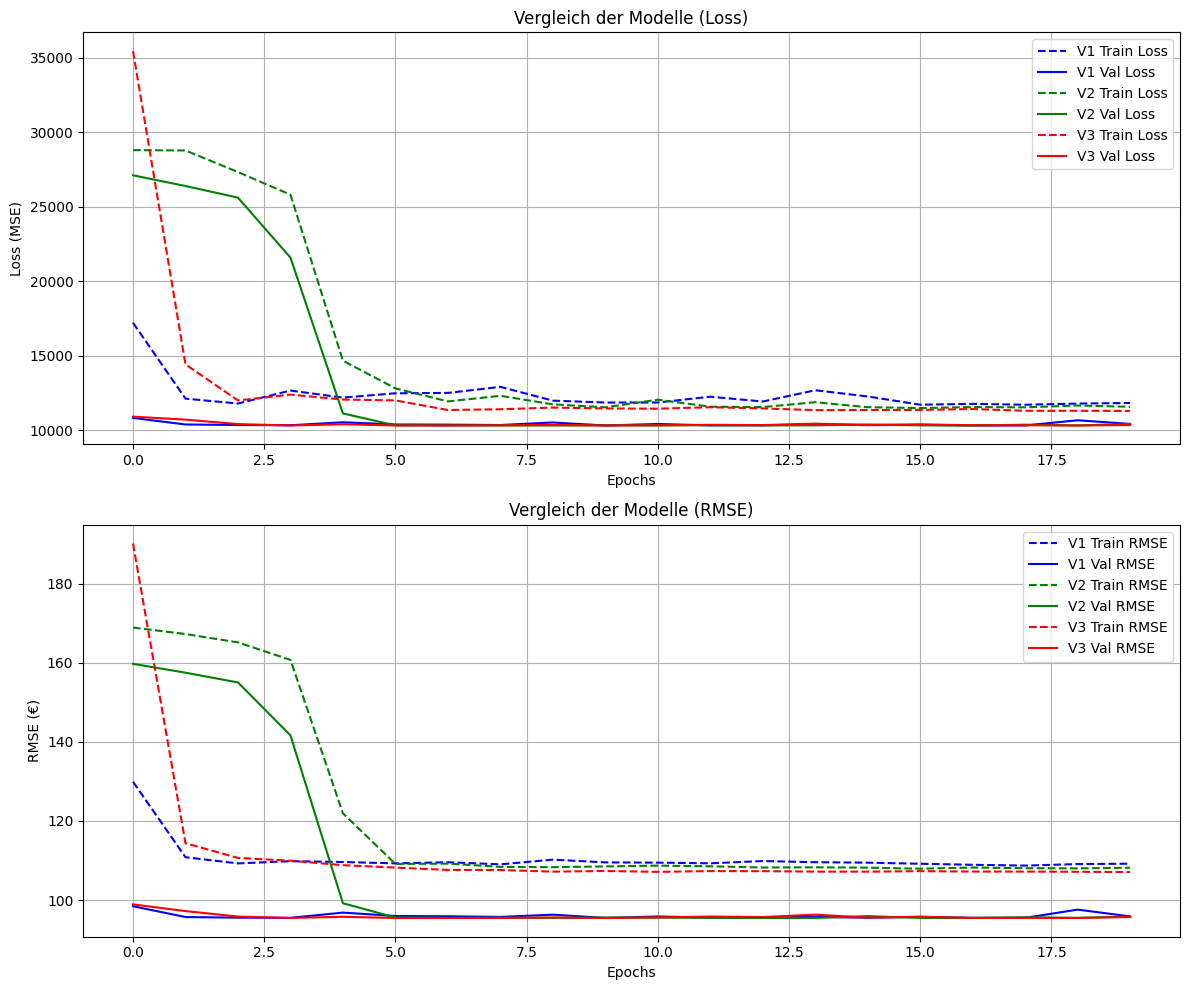


--- Beste Ergebnisse (Validation RMSE) ---
Modell V1: Bester Epoch 10 | Val RMSE: 95.46€
Modell V2: Bester Epoch 17 | Val RMSE: 95.45€
Modell V3: Bester Epoch 19 | Val RMSE: 95.45€

🏆 GEWINNER: Modell V3 mit einem RMSE von 95.45€


In [19]:

fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# 1. PLOT: LOSS (MSE)
axs[0].plot(train_losses_V1, label='V1 Train Loss', linestyle='--', color='blue')
axs[0].plot(val_losses_V1, label='V1 Val Loss', color='blue')

axs[0].plot(train_losses_V2, label='V2 Train Loss', linestyle='--', color='green')
axs[0].plot(val_losses_V2, label='V2 Val Loss', color='green')

axs[0].plot(train_losses_V3, label='V3 Train Loss', linestyle='--', color='red')
axs[0].plot(val_losses_V3, label='V3 Val Loss', color='red')

axs[0].set_title('Vergleich der Modelle (Loss)')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss (MSE)')
axs[0].legend()
axs[0].grid(True)

# 2. PLOT: RMSE
axs[1].plot(train_rmses_V1, label='V1 Train RMSE', linestyle='--', color='blue')
axs[1].plot(val_rmses_V1, label='V1 Val RMSE', color='blue')

axs[1].plot(train_rmses_V2, label='V2 Train RMSE', linestyle='--', color='green')
axs[1].plot(val_rmses_V2, label='V2 Val RMSE', color='green')

axs[1].plot(train_rmses_V3, label='V3 Train RMSE', linestyle='--', color='red')
axs[1].plot(val_rmses_V3, label='V3 Val RMSE', color='red')

axs[1].set_title('Vergleich der Modelle (RMSE)')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('RMSE (€)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# --- BESTE EPOCHS FINDEN ---
print("\n--- Beste Ergebnisse (Validation RMSE) ---")

best_epoch_V1 = np.argmin(val_rmses_V1)
best_rmse_V1 = val_rmses_V1[best_epoch_V1]
print(f"Modell V1: Bester Epoch {best_epoch_V1+1} | Val RMSE: {best_rmse_V1:.2f}€")

best_epoch_V2 = np.argmin(val_rmses_V2)
best_rmse_V2 = val_rmses_V2[best_epoch_V2]
print(f"Modell V2: Bester Epoch {best_epoch_V2+1} | Val RMSE: {best_rmse_V2:.2f}€")

best_epoch_V3 = np.argmin(val_rmses_V3)
best_rmse_V3 = val_rmses_V3[best_epoch_V3]
print(f"Modell V3: Bester Epoch {best_epoch_V3+1} | Val RMSE: {best_rmse_V3:.2f}€")

# Gewinner ermitteln
winner = min([(best_rmse_V1, 'V1'), (best_rmse_V2, 'V2'), (best_rmse_V3, 'V3')])
print(f"\n🏆 GEWINNER: Modell {winner[1]} mit einem RMSE von {winner[0]:.2f}€")

Starte Hyperparameter-Test für 4 Learning Rates...

--- Teste Learning Rate: 0.1 ---
Ergebnis LR 0.1: Finaler Val Loss (MSE) = 10380.5477

--- Teste Learning Rate: 0.01 ---
Ergebnis LR 0.01: Finaler Val Loss (MSE) = 10312.4910

--- Teste Learning Rate: 0.001 ---
Ergebnis LR 0.001: Finaler Val Loss (MSE) = 10312.4559

--- Teste Learning Rate: 0.0001 ---
Ergebnis LR 0.0001: Finaler Val Loss (MSE) = 25435.7054


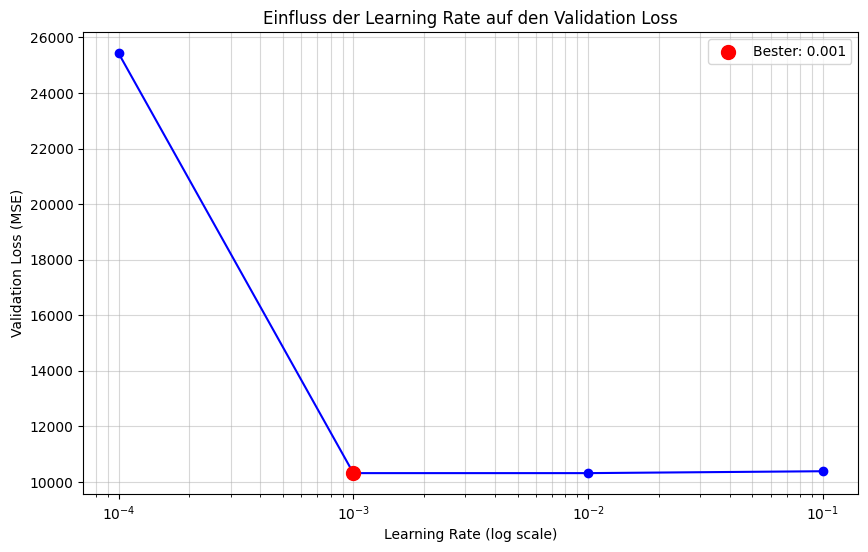

Starte Hyperparameter-Test für 4 Learning Rates...

--- Teste Learning Rate: 0.1 ---
Ergebnis LR 0.1: Finaler Val Loss (MSE) = 10308.2565

--- Teste Learning Rate: 0.01 ---
Ergebnis LR 0.01: Finaler Val Loss (MSE) = 10335.0908

--- Teste Learning Rate: 0.001 ---
Ergebnis LR 0.001: Finaler Val Loss (MSE) = 10319.6785

--- Teste Learning Rate: 0.0001 ---
Ergebnis LR 0.0001: Finaler Val Loss (MSE) = 25817.5934


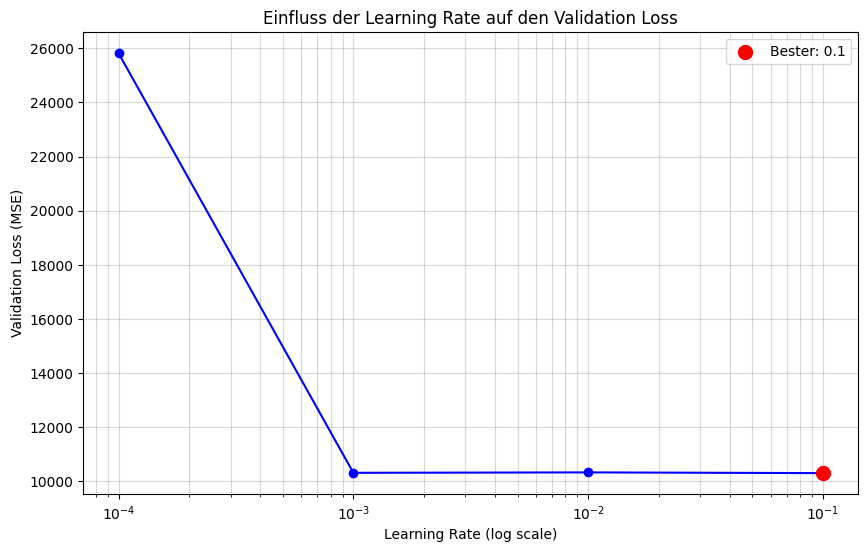

Starte Hyperparameter-Test für 4 Learning Rates...

--- Teste Learning Rate: 0.1 ---
Ergebnis LR 0.1: Finaler Val Loss (MSE) = 10317.3144

--- Teste Learning Rate: 0.01 ---
Ergebnis LR 0.01: Finaler Val Loss (MSE) = 10310.1692

--- Teste Learning Rate: 0.001 ---
Ergebnis LR 0.001: Finaler Val Loss (MSE) = 10315.8810

--- Teste Learning Rate: 0.0001 ---
Ergebnis LR 0.0001: Finaler Val Loss (MSE) = 25935.8411


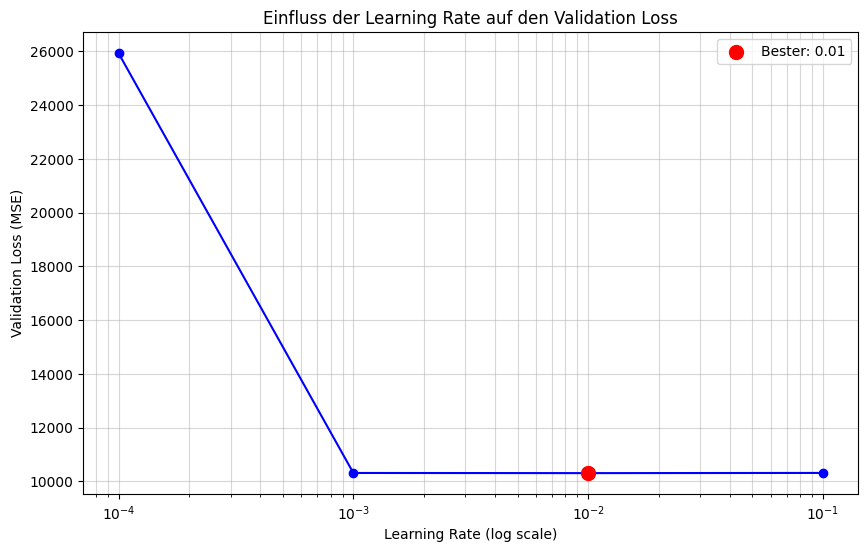

In [20]:
learning_rates = [0.1,0.01,0.001,0.0001]

best_lr_V1, best_loss_V2 = test_learning_rates(
    learning_rates=learning_rates,
    model_class=MLPModel,
    input_dim=512,
    output_dim=1,
    train_loader=train_loader_img,
    val_loader=val_loader_img,
    device=device,
    epochs=50
)

best_lr_V1, best_loss_V2 = test_learning_rates(
    learning_rates=learning_rates,
    model_class=MLPModel,
    input_dim=512,
    output_dim=1,
    train_loader=train_loader_img,
    val_loader=val_loader_img,
    device=device,
    epochs=50
)

best_lr_V3, best_loss_V3 = test_learning_rates(
    learning_rates=learning_rates,
    model_class=MLPModel,
    input_dim=512,
    output_dim=1,
    train_loader=train_loader_img,
    val_loader=val_loader_img,
    device=device,
    epochs=50
)



In [21]:
def extract_features_resnet50(url_list):
    """
    Extrahiert Features mit ResNet50 (2048 Dimensionen).
    """
    # 1. Modell laden (pretrained)
    resnet = models.resnet50(pretrained=True)
    
    # 2. Den letzten Layer (Classifier) entfernen, um nur Features zu bekommen
    # ResNet50 endet mit (avgpool): Output ist (Batch, 2048, 1, 1)
    # Wir entfernen alles nach dem Pooling oder nutzen Sequential bis zum Pooling
    resnet = nn.Sequential(*list(resnet.children())[:-1]) # Entfernt den fc Layer
    
    resnet.eval() # Evaluation mode
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    resnet.to(device)
    
    # 3. Transformationen definieren (ResNet braucht spezifische Normalisierung)
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    features_list = []
    
    print(f"Starte Extraktion mit ResNet50 für {len(url_list)} Bilder...")
    
    for url in tqdm(url_list, desc="ResNet50 Extraktion"):
        try:
            response = requests.get(url, timeout=5)
            img = Image.open(requests.get(url, stream=True).raw).convert('RGB')
            img_tensor = preprocess(img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                feature_vector = resnet(img_tensor)
            
            # Shape ist (Batch, 2048, 1, 1) -> wir wollen (2048)
            feature_vector = feature_vector.flatten().cpu().numpy()
            features_list.append(feature_vector)
            
        except Exception as e:
            # Bei Fehler: Null-Vektor der Länge 2048
            features_list.append(np.zeros(2048))
            
    return np.array(features_list)

In [22]:
image_path_50 = 'X_images_resnet50.npy'

if os.path.exists(image_path_50):
    print("Lade ResNet50 Features...")
    X_images_50 = np.load(image_path_50, allow_pickle=True)
else:
    print("Berechne ResNet50 Features (das kann dauern!)...")
    # Annahme: df ist geladen und 'urls' sind definiert
    X_images_50 = extract_features_resnet50(urls)
    np.save(image_path_50, X_images_50)
    print(f"Gespeichert! Shape: {X_images.shape}")

Berechne ResNet50 Features (das kann dauern!)...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


Starte Extraktion mit ResNet50 für 9229 Bilder...


ResNet50 Extraktion: 100%|██████████| 9229/9229 [00:00<00:00, 80192.48it/s]


Gespeichert! Shape: (9229, 512)


In [23]:
X_train_img, X_val_img, X_test_img, y_train, y_val, y_test = split_data(X_images_50, y)
X_train_img_scaled, X_val_img_scaled, X_test_img_scaled = standardize_data(
    X_train_img,
    X_val_img,
    X_test_img)
train_loader_img, val_loader_img, test_loader_img = create_dataloaders(
    X_train=X_train_img_scaled,
    X_val=X_val_img_scaled,
    X_test=X_test_img_scaled,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    batch_size=batch_size
)

Split: Train=6460, Val=1384, Test=1385
Scaling abgeschlossen.
DataLoader bereit (Batch Size 256):
  Train Batches: 26
  Val Batches: 6
  Test Batches: 6


Starte Hyperparameter-Test für 4 Learning Rates (20 Epochen)...

--- Teste Learning Rate: 0.01 ---
LR 0.01 beendet. Finaler Val Loss: 15961.0339

--- Teste Learning Rate: 0.001 ---
LR 0.001 beendet. Finaler Val Loss: 15997.5478

--- Teste Learning Rate: 0.0001 ---
LR 0.0001 beendet. Finaler Val Loss: 34122.6406

--- Teste Learning Rate: 1e-05 ---
LR 1e-05 beendet. Finaler Val Loss: 34376.3623


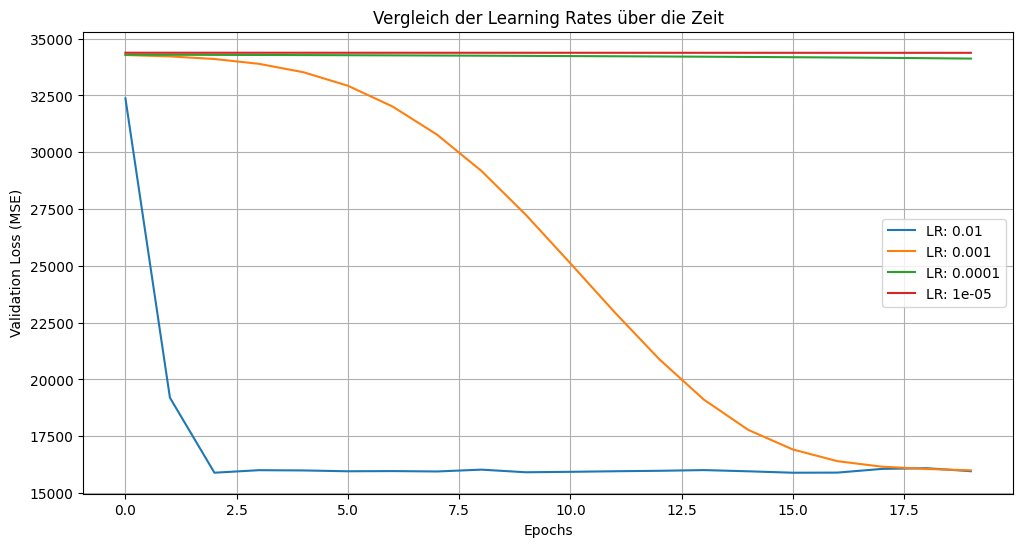


Bester finaler Val Loss bei LR: 0.01


In [24]:
learning_rates = [0.01,0.001,0.0001,0.00001]

all_val_losses = test_learning_rates_curves(
    learning_rates=learning_rates,
    model_class=MLPModel,
    input_dim=2048,
    output_dim=1,
    train_loader=train_loader_img,
    val_loader=val_loader_img,
    device=device,
    epochs=20
)

Starte Hyperparameter-Test für 3 Learning Rates (100 Epochen)...

--- Teste Learning Rate: 0.0001 ---
LR 0.0001 beendet. Finaler Val Loss: 23080.3298

--- Teste Learning Rate: 1e-05 ---
LR 1e-05 beendet. Finaler Val Loss: 34272.0007

--- Teste Learning Rate: 1e-06 ---
LR 1e-06 beendet. Finaler Val Loss: 34337.4443


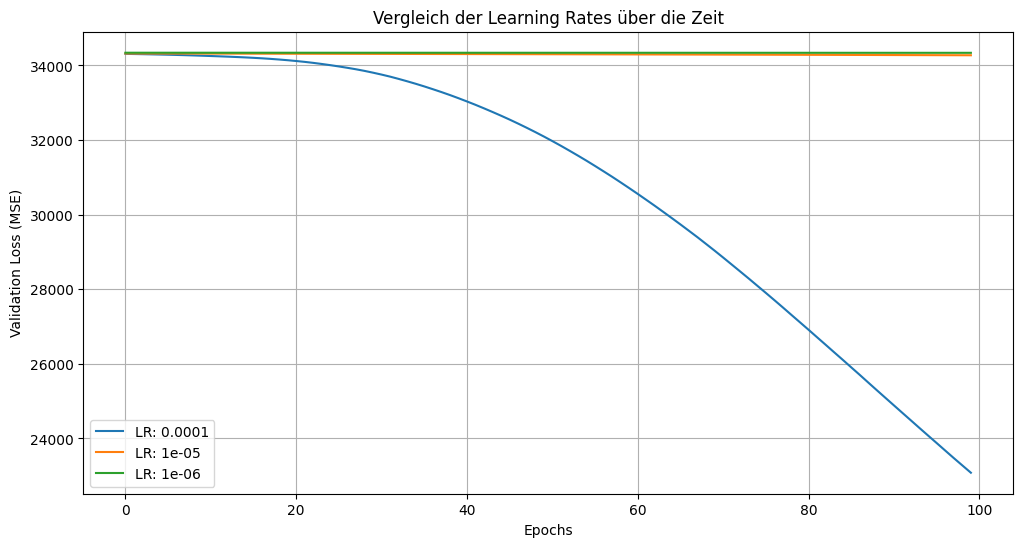


Bester finaler Val Loss bei LR: 0.0001


In [25]:
learning_rates = [0.0001,0.00001,0.000001]

all_loses = test_learning_rates_curves(
    learning_rates=learning_rates,
    model_class=MLPModel,
    input_dim=2048,
    output_dim=1,
    train_loader=train_loader_img,
    val_loader=val_loader_img,
    device=device,
    epochs=100
)


In [26]:
img_model_resnet50 = WideMLPModel(input_dim=2048, output_dim=1).to(device)

optimizer = torch.optim.AdamW(img_model_resnet50.parameters(), lr=0.0001)
loss_fn = torch.nn.MSELoss()

In [27]:
train_losses, val_losses, train_rmses, val_rmses = run_training(
    model=img_model_resnet50,
    optimizer=optimizer,
    loss_function=loss_fn,
    device=device,
    num_epochs=100,
    train_dataloader=train_loader_img,
    val_dataloader=val_loader_img
)

Starte Training für 100 Epochen...


<div><p>Epoch 1/100 | Train Loss (MSE): 27371.1624 | Train RMSE:       166.01€ | Val Loss (MSE):   34359.8574 | Val RMSE:         186.89€</p><p>Epoch 2/100 | Train Loss (MSE): 27357.3845 | Train RMSE:       165.78€ | Val Loss (MSE):   34331.0186 | Val RMSE:         186.81€</p><p>Epoch 3/100 | Train Loss (MSE): 27293.1197 | Train RMSE:       165.54€ | Val Loss (MSE):   34126.3730 | Val RMSE:         186.26€</p><p>Epoch 4/100 | Train Loss (MSE): 28005.3616 | Train RMSE:       165.33€ | Val Loss (MSE):   29676.0605 | Val RMSE:         173.79€</p><p>Epoch 5/100 | Train Loss (MSE): 27702.3585 | Train RMSE:       165.10€ | Val Loss (MSE):   27623.2863 | Val RMSE:         167.71€</p><p>Epoch 6/100 | Train Loss (MSE): 27083.6041 | Train RMSE:       164.87€ | Val Loss (MSE):   24677.6883 | Val RMSE:         158.59€</p><p>Epoch 7/100 | Train Loss (MSE): 27120.8444 | Train RMSE:       164.64€ | Val Loss (MSE):   23859.9204 | Val RMSE:         155.95€</p><p>Epoch 8/100 | Train Loss (MSE): 26988.6490 | Train RMSE:       164.41€ | Val Loss (MSE):   25009.0358 | Val RMSE:         159.64€</p><p>Epoch 9/100 | Train Loss (MSE): 26662.6381 | Train RMSE:       164.18€ | Val Loss (MSE):   23341.3296 | Val RMSE:         154.26€</p><p>Epoch 10/100 | Train Loss (MSE): 26759.7094 | Train RMSE:       163.95€ | Val Loss (MSE):   21680.2917 | Val RMSE:         148.70€</p><p>Epoch 11/100 | Train Loss (MSE): 26532.3257 | Train RMSE:       163.70€ | Val Loss (MSE):   21339.5661 | Val RMSE:         147.54€</p><p>Epoch 12/100 | Train Loss (MSE): 26557.8703 | Train RMSE:       163.46€ | Val Loss (MSE):   17604.7543 | Val RMSE:         134.01€</p><p>Epoch 13/100 | Train Loss (MSE): 26574.1013 | Train RMSE:       163.23€ | Val Loss (MSE):   17614.1639 | Val RMSE:         134.05€</p><p>Epoch 14/100 | Train Loss (MSE): 26356.8555 | Train RMSE:       162.99€ | Val Loss (MSE):   17371.4639 | Val RMSE:         133.11€</p><p>Epoch 15/100 | Train Loss (MSE): 26954.4984 | Train RMSE:       162.74€ | Val Loss (MSE):   19982.6619 | Val RMSE:         142.79€</p><p>Epoch 16/100 | Train Loss (MSE): 26224.9869 | Train RMSE:       162.49€ | Val Loss (MSE):   17603.3995 | Val RMSE:         134.01€</p><p>Epoch 17/100 | Train Loss (MSE): 26115.2368 | Train RMSE:       162.25€ | Val Loss (MSE):   15943.1128 | Val RMSE:         127.36€</p><p>Epoch 18/100 | Train Loss (MSE): 26202.2521 | Train RMSE:       162.00€ | Val Loss (MSE):   18770.8937 | Val RMSE:         138.39€</p><p>Epoch 19/100 | Train Loss (MSE): 26059.6825 | Train RMSE:       161.74€ | Val Loss (MSE):   16579.0943 | Val RMSE:         130.00€</p><p>Epoch 20/100 | Train Loss (MSE): 26273.6565 | Train RMSE:       161.47€ | Val Loss (MSE):   18354.1033 | Val RMSE:         136.85€</p><p>Epoch 21/100 | Train Loss (MSE): 25821.9292 | Train RMSE:       161.21€ | Val Loss (MSE):   17449.4277 | Val RMSE:         133.41€</p><p>Epoch 22/100 | Train Loss (MSE): 25783.1699 | Train RMSE:       160.95€ | Val Loss (MSE):   16608.9631 | Val RMSE:         130.12€</p><p>Epoch 23/100 | Train Loss (MSE): 25598.4444 | Train RMSE:       160.67€ | Val Loss (MSE):   16700.6547 | Val RMSE:         130.48€</p><p>Epoch 24/100 | Train Loss (MSE): 26261.0451 | Train RMSE:       160.40€ | Val Loss (MSE):   16361.8577 | Val RMSE:         129.12€</p><p>Epoch 25/100 | Train Loss (MSE): 25675.7992 | Train RMSE:       160.13€ | Val Loss (MSE):   16046.7981 | Val RMSE:         127.81€</p><p>Epoch 26/100 | Train Loss (MSE): 25683.3943 | Train RMSE:       159.82€ | Val Loss (MSE):   17444.5148 | Val RMSE:         133.39€</p><p>Epoch 27/100 | Train Loss (MSE): 25860.9677 | Train RMSE:       159.57€ | Val Loss (MSE):   15882.8651 | Val RMSE:         127.06€</p><p>Epoch 28/100 | Train Loss (MSE): 25177.3472 | Train RMSE:       159.27€ | Val Loss (MSE):   16106.4396 | Val RMSE:         128.07€</p><p>Epoch 29/100 | Train Loss (MSE): 25093.7337 | Train RMSE:       158.98€ | Val Loss (MSE):   17063.5546 | Val RMSE:         131.92€</p><p>Epoch 30/100 | Train Loss (M

Training beendet.


In [28]:
# Modell initialisieren
deep_model = DeepResidualMLP(input_dim=2048, output_dim=1).to(device)

# Optimizer
optimizer = torch.optim.AdamW(deep_model.parameters(), lr=0.00001) # 0.001 ist bei ResNets oft besser

# Training
history = run_training(
    model=deep_model,
    optimizer=optimizer,
    loss_function=loss_fn,
    device=device,
    num_epochs=20,
    train_dataloader=train_loader_img,
    val_dataloader=val_loader_img
)

Starte Training für 20 Epochen...


<div><p>Epoch 1/20 | Train Loss (MSE): 27730.7764 | Train RMSE:       165.84€ | Val Loss (MSE):   34285.8555 | Val RMSE:         186.69€</p><p>Epoch 2/20 | Train Loss (MSE): 28688.2611 | Train RMSE:       165.74€ | Val Loss (MSE):   34257.4811 | Val RMSE:         186.61€</p><p>Epoch 3/20 | Train Loss (MSE): 27215.5898 | Train RMSE:       165.64€ | Val Loss (MSE):   27844.1117 | Val RMSE:         168.38€</p><p>Epoch 4/20 | Train Loss (MSE): 27308.6033 | Train RMSE:       165.55€ | Val Loss (MSE):   5744795.0000 | Val RMSE:         2395.76€</p><p>Epoch 5/20 | Train Loss (MSE): 27260.0491 | Train RMSE:       165.46€ | Val Loss (MSE):   395749002.6667 | Val RMSE:         19892.32€</p><p>Epoch 6/20 | Train Loss (MSE): 27233.7076 | Train RMSE:       165.37€ | Val Loss (MSE):   784346101.3333 | Val RMSE:         28005.06€</p><p>Epoch 7/20 | Train Loss (MSE): 27585.8105 | Train RMSE:       165.27€ | Val Loss (MSE):   873683936.0000 | Val RMSE:         29557.02€</p><p>Epoch 8/20 | Train Loss (MSE): 27215.1604 | Train RMSE:       165.16€ | Val Loss (MSE):   506767130.6667 | Val RMSE:         22510.37€</p><p>Epoch 9/20 | Train Loss (MSE): 27151.7250 | Train RMSE:       165.07€ | Val Loss (MSE):   658891541.3333 | Val RMSE:         25667.76€</p><p>Epoch 10/20 | Train Loss (MSE): 26894.2971 | Train RMSE:       164.97€ | Val Loss (MSE):   1056700533.3333 | Val RMSE:         32505.81€</p><p>Epoch 11/20 | Train Loss (MSE): 27073.3538 | Train RMSE:       164.90€ | Val Loss (MSE):   1507618133.3333 | Val RMSE:         38826.93€</p><p>Epoch 12/20 | Train Loss (MSE): 26942.6376 | Train RMSE:       164.79€ | Val Loss (MSE):   2631501866.6667 | Val RMSE:         51297.04€</p><p>Epoch 13/20 | Train Loss (MSE): 27192.5002 | Train RMSE:       164.70€ | Val Loss (MSE):   1752555008.0000 | Val RMSE:         41862.40€</p><p>Epoch 14/20 | Train Loss (MSE): 27184.3730 | Train RMSE:       164.62€ | Val Loss (MSE):   2657804928.0000 | Val RMSE:         51552.78€</p><p>Epoch 15/20 | Train Loss (MSE): 26795.0766 | Train RMSE:       164.52€ | Val Loss (MSE):   1730598826.6667 | Val RMSE:         41599.34€</p><p>Epoch 16/20 | Train Loss (MSE): 27822.8775 | Train RMSE:       164.42€ | Val Loss (MSE):   2044313792.0000 | Val RMSE:         45212.96€</p><p>Epoch 17/20 | Train Loss (MSE): 26736.8051 | Train RMSE:       164.34€ | Val Loss (MSE):   3080566400.0000 | Val RMSE:         55501.73€</p><p>Epoch 18/20 | Train Loss (MSE): 26691.1415 | Train RMSE:       164.25€ | Val Loss (MSE):   2316061482.6667 | Val RMSE:         48124.35€</p><p>Epoch 19/20 | Train Loss (MSE): 26687.9972 | Train RMSE:       164.14€ | Val Loss (MSE):   2037870954.6667 | Val RMSE:         45141.66€</p><p>Epoch 20/20 | Train Loss (MSE): 27699.8356 | Train RMSE:       164.06€ | Val Loss (MSE):   2921668736.0000 | Val RMSE:         54051.34€</p></div>

Training beendet.


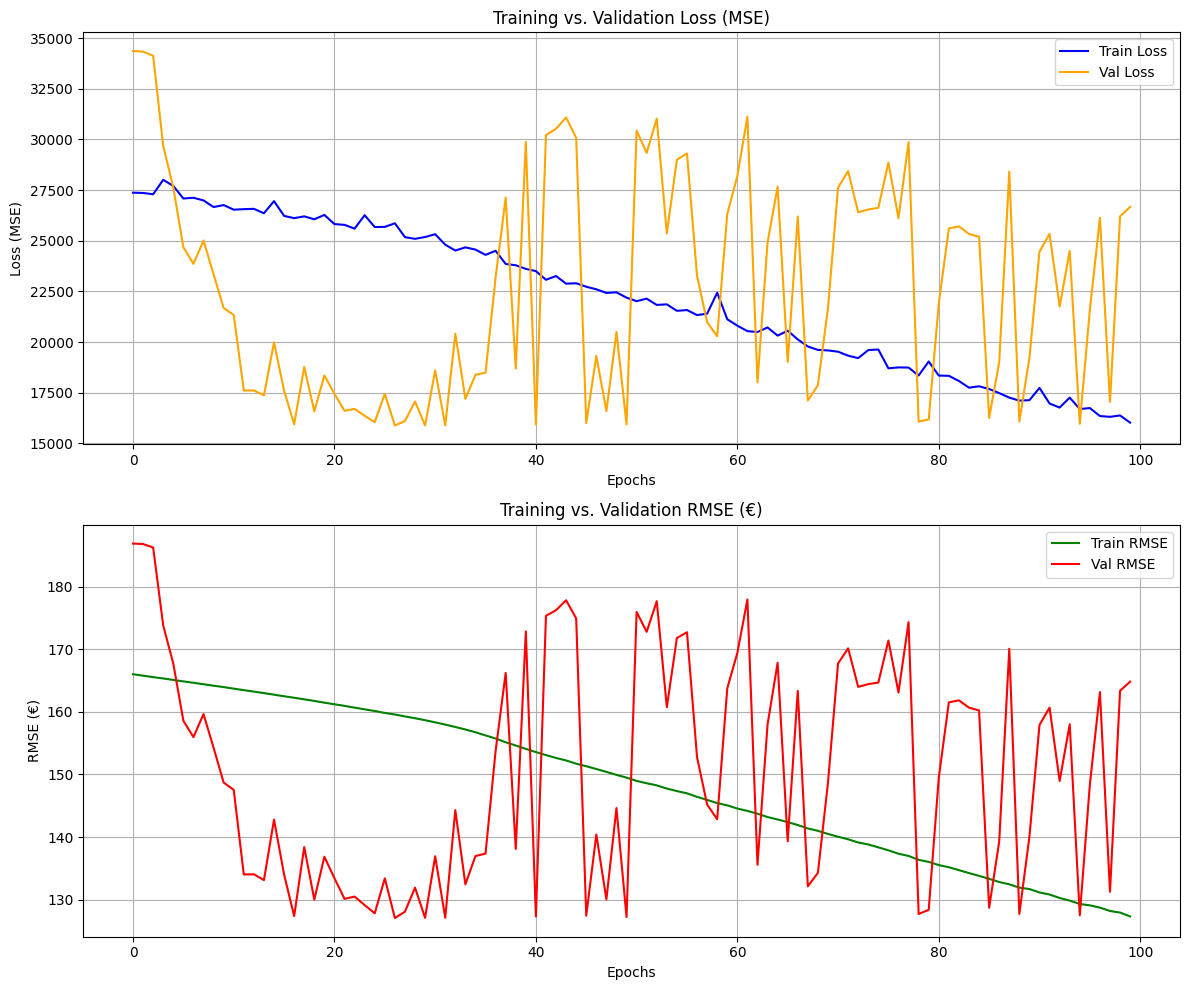

Beste Epoche: 27
Bester Validation RMSE: 127.06€


In [29]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# 1. PLOT: LOSS (MSE)
axs[0].plot(train_losses, label='Train Loss', color='blue')
axs[0].plot(val_losses, label='Val Loss', color='orange')

axs[0].set_title('Training vs. Validation Loss (MSE)')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss (MSE)')
axs[0].legend()
axs[0].grid(True)

# 2. PLOT: RMSE
axs[1].plot(train_rmses, label='Train RMSE', color='green')
axs[1].plot(val_rmses, label='Val RMSE', color='red')

axs[1].set_title('Training vs. Validation RMSE (€)')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('RMSE (€)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

best_epoch = np.argmin(val_rmses)
best_val_rmse = val_rmses[best_epoch]

print(f"Beste Epoche: {best_epoch + 1}")
print(f"Bester Validation RMSE: {best_val_rmse:.2f}€")


Lade Rohbilder für Synchronisation...
Rekonstruiere Split basierend auf Tabellen-Daten:
Total: 9229, Train: 6460, Val: 1384
Bilder synchronisiert: Train=6460, Val=1384, Test=1385
Füge Tabellen und Bilder zusammen...
Finaler Multi-Modal Shape Train: (6460, 2126)
DataLoader bereit (Batch Size 64):
  Train Batches: 101
  Val Batches: 22
  Test Batches: 22
Starte Hyperparameter-Test für 5 Learning Rates...

--- Teste Learning Rate: 0.01 ---
Ergebnis LR 0.01: Finaler Val Loss (MSE) = 16278.5010

--- Teste Learning Rate: 0.001 ---
Ergebnis LR 0.001: Finaler Val Loss (MSE) = 16195.9270

--- Teste Learning Rate: 0.0001 ---
Ergebnis LR 0.0001: Finaler Val Loss (MSE) = 16914.3558

--- Teste Learning Rate: 1e-05 ---
Ergebnis LR 1e-05: Finaler Val Loss (MSE) = 34557.9639

--- Teste Learning Rate: 1e-06 ---
Ergebnis LR 1e-06: Finaler Val Loss (MSE) = 34587.7678


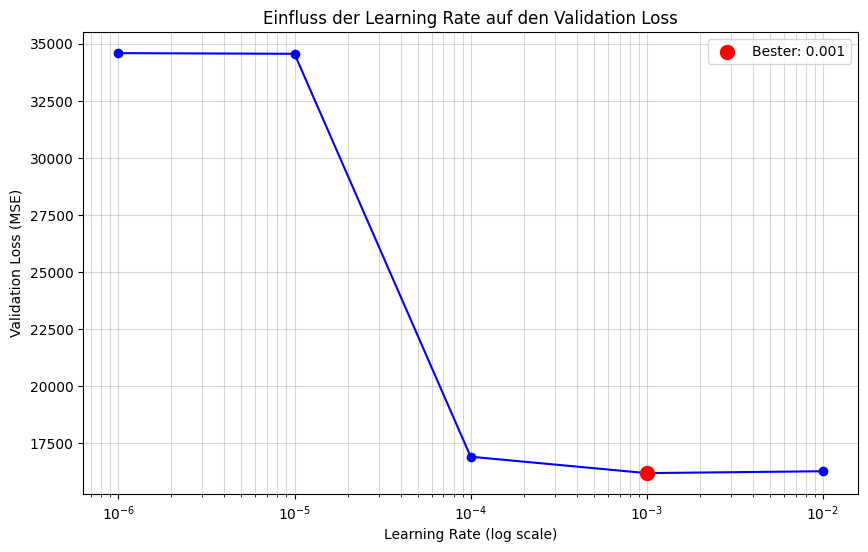

In [30]:
import numpy as np
import sys
sys.path.append('/kaggle/working/Machine-Learning-Final-project')

from src.data.dataset import create_dataloaders

# --- 1. LADEN DER ROHBILDER ---
print("Lade Rohbilder für Synchronisation...")
X_images_raw = np.load('X_images_resnet50.npy', allow_pickle=True)

# --- 2. REKONSTRUKTION DER INDIZES ---

n_total = len(X_train_scaled) + len(X_val_scaled) + len(X_test_scaled)
n_train = len(X_train_scaled)
n_val = len(X_val_scaled)

print(f"Rekonstruiere Split basierend auf Tabellen-Daten:")
print(f"Total: {n_total}, Train: {n_train}, Val: {n_val}")

# Bilder manuell aufteilen (basierend auf Tabellen-Indizes)
X_img_train = X_images_raw[:n_train]
X_img_val = X_images_raw[n_train : n_train + n_val]
X_img_test = X_images_raw[n_train + n_val :]

print(f"Bilder synchronisiert: Train={len(X_img_train)}, Val={len(X_img_val)}, Test={len(X_img_test)}")

# --- 3. SCALING DER BILDER ---
# Wir skalieren die Bilder separat (Mean/Std vom Trainingsset)
mean_img = X_img_train.mean(axis=0)
std_img = X_img_train.std(axis=0)
std_img[std_img == 0] = 1.0

X_img_train_s = (X_img_train - mean_img) / std_img
X_img_val_s = (X_img_val - mean_img) / std_img
X_img_test_s = (X_img_test - mean_img) / std_img

# --- 4. ZUSAMMENFÜHREN (CONCATENATION) ---
print("Füge Tabellen und Bilder zusammen...")

# X_train_scaled enthält bereits Tabellen + Spatial (bereits skaliert)
X_train_multi = np.concatenate((X_train_scaled, X_img_train_s), axis=1)
X_val_multi = np.concatenate((X_val_scaled, X_img_val_s), axis=1)
X_test_multi = np.concatenate((X_test_scaled, X_img_test_s), axis=1)

print(f"Finaler Multi-Modal Shape Train: {X_train_multi.shape}")

# --- 5. DATALOADER ERSTELLEN ---
train_loader_multi, val_loader_multi, test_loader_multi = create_dataloaders(
    X_train=X_train_multi,
    X_val=X_val_multi,
    X_test=X_test_multi,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    batch_size=64
)

# --- 6. MODELL DEFINIEREN ---
sample_inputs, _ = next(iter(train_loader_multi))
input_dim = sample_inputs.shape[1]

learning_rates = [0.01,0.001,0.0001,0.00001,0.000001]

best_lr, best_loss = test_learning_rates(
    learning_rates=learning_rates,
    model_class=MLPModel,
    input_dim=input_dim,
    output_dim=1,
    train_loader=train_loader_multi,
    val_loader=val_loader_multi,
    device=device,
    epochs=20
)

In [31]:
print(f"Training Multi-Modal MLP mit Input Dim: {input_dim}")
sample_inputs, _ = next(iter(train_loader_multi))
input_dim = sample_inputs.shape[1]
multi_model = DeepResidualMLP(input_dim=input_dim, output_dim=1).to(device)

optimizer = torch.optim.AdamW(multi_model.parameters(), lr=0.0001)
loss_function = torch.nn.MSELoss()

history = run_training(
    model=multi_model,
    optimizer=optimizer,
    loss_function=loss_fn,
    device=device,
    num_epochs=20,
    train_dataloader=train_loader_multi,
    val_dataloader=val_loader_multi
)


Training Multi-Modal MLP mit Input Dim: 2126
Starte Training für 20 Epochen...


<div><p>Epoch 1/20 | Train Loss (MSE): 26819.4609 | Train RMSE:       163.76€ | Val Loss (MSE):   33027.9468 | Val RMSE:         182.66€</p><p>Epoch 2/20 | Train Loss (MSE): 25252.6259 | Train RMSE:       158.92€ | Val Loss (MSE):   31602.4448 | Val RMSE:         178.69€</p><p>Epoch 3/20 | Train Loss (MSE): 23941.4913 | Train RMSE:       154.75€ | Val Loss (MSE):   30316.6937 | Val RMSE:         175.06€</p><p>Epoch 4/20 | Train Loss (MSE): 22645.2695 | Train RMSE:       150.50€ | Val Loss (MSE):   29259.0889 | Val RMSE:         172.00€</p><p>Epoch 5/20 | Train Loss (MSE): 21310.1989 | Train RMSE:       145.98€ | Val Loss (MSE):   27631.7131 | Val RMSE:         167.16€</p><p>Epoch 6/20 | Train Loss (MSE): 19893.2971 | Train RMSE:       141.06€ | Val Loss (MSE):   26041.4128 | Val RMSE:         162.31€</p><p>Epoch 7/20 | Train Loss (MSE): 18489.5039 | Train RMSE:       135.93€ | Val Loss (MSE):   24758.7569 | Val RMSE:         158.29€</p><p>Epoch 8/20 | Train Loss (MSE): 17127.4226 | Train RMSE:       130.88€ | Val Loss (MSE):   23206.1424 | Val RMSE:         153.28€</p><p>Epoch 9/20 | Train Loss (MSE): 15963.9499 | Train RMSE:       126.36€ | Val Loss (MSE):   22099.9365 | Val RMSE:         149.60€</p><p>Epoch 10/20 | Train Loss (MSE): 14895.8920 | Train RMSE:       122.07€ | Val Loss (MSE):   21299.7449 | Val RMSE:         146.88€</p><p>Epoch 11/20 | Train Loss (MSE): 14077.3700 | Train RMSE:       118.66€ | Val Loss (MSE):   20041.5342 | Val RMSE:         142.50€</p><p>Epoch 12/20 | Train Loss (MSE): 13253.6101 | Train RMSE:       115.12€ | Val Loss (MSE):   19219.1400 | Val RMSE:         139.55€</p><p>Epoch 13/20 | Train Loss (MSE): 12604.5910 | Train RMSE:       112.28€ | Val Loss (MSE):   18672.5614 | Val RMSE:         137.56€</p><p>Epoch 14/20 | Train Loss (MSE): 12166.0826 | Train RMSE:       110.31€ | Val Loss (MSE):   18227.3759 | Val RMSE:         135.92€</p><p>Epoch 15/20 | Train Loss (MSE): 11722.3934 | Train RMSE:       108.28€ | Val Loss (MSE):   17882.2142 | Val RMSE:         134.62€</p><p>Epoch 16/20 | Train Loss (MSE): 11353.7950 | Train RMSE:       106.57€ | Val Loss (MSE):   17384.3565 | Val RMSE:         132.72€</p><p>Epoch 17/20 | Train Loss (MSE): 11102.4757 | Train RMSE:       105.37€ | Val Loss (MSE):   17137.6112 | Val RMSE:         131.77€</p><p>Epoch 18/20 | Train Loss (MSE): 10907.0219 | Train RMSE:       104.44€ | Val Loss (MSE):   17031.1948 | Val RMSE:         131.35€</p><p>Epoch 19/20 | Train Loss (MSE): 10796.5934 | Train RMSE:       103.91€ | Val Loss (MSE):   16760.2626 | Val RMSE:         130.30€</p><p>Epoch 20/20 | Train Loss (MSE): 10694.0502 | Train RMSE:       103.38€ | Val Loss (MSE):   16540.1820 | Val RMSE:         129.42€</p></div>

Training beendet.
